# DAI Mission — Final Project Deliverable
**Data & AI in Economics | TU Dortmund University**

## 1. Team
| Role | Name | Student ID |
| :--- | :--- | :--- |
| **Lead** | Leila Rahimiyadkuri | [Your ID] |
| **Member** | Forough Asgari | [Your ID] |
| **Member** | Sara Davoodabadi | [Your ID] |

> **AI Disclosure:** We utilized an LLM assistant to aid in phrasal structuring, grammatical optimization, and code syntax organization throughout this deliverable. All core analytical configurations, structural causal modeling assumptions, machine learning evaluation criteria, and economic synthesis are uniquely designed and verified by the authors.

## 2. Mission Title & Research Question

* **Mission Title:** Predicting and Explaining Customer Churn in Telecommunications: A Unified Approach Combining Graphical Causal AI, Supervised Classifiers, and Customer Segmentation.
* **Research Question:** Does the type of contract a telecom customer holds (*month-to-month* vs. *longer-term*) causally increase their probability of churning ($Y$) — and does this treatment effect vary significantly across distinct customer archetypes discovered via unsupervised learning?

In [1]:
# Import core data science libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries matching TU Dortmund module workshops
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Download dataset via kagglehub natively
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# --- Clean Known Data Quality Issues ---
# Fix TotalCharges string-to-numeric type conversion error
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Drop the 11 rows where tenure = 0

# Map target variable to binary integers
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Environment setup successful! Dataset shape:", df.shape)

100%|██████████| 172k/172k [00:00<00:00, 467kB/s]

Extracting files...
Environment setup successful! Dataset shape: (7032, 22)


## 3. Data
We use the IBM Telco Customer Churn dataset from Kaggle.
* **Unit of observation:** One individual telecom customer.
* **Target ($Y$):** `Churn` (Yes/No mapped to 1/0).
* **Treatment ($W_1$):** `Contract` (Month-to-month, One year, Two year).
* **Confounders ($X$):** `tenure`, `SeniorCitizen`, `Partner`, `Dependents`.

In [2]:
# Import core data science libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries matching TU Dortmund module workshops
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Download dataset via kagglehub natively
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

# --- Clean Known Data Quality Issues ---
# Fix TotalCharges string-to-numeric type conversion error
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Drop the 11 rows where tenure = 0

# Map target variable to binary integers
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Environment setup successful! Dataset shape:", df.shape)

Environment setup successful! Dataset shape: (7032, 22)


### 3a. Target Variable Distribution & Class Imbalance Analysis
Before training any supervised classifiers, we must analyze the distribution of our target variable, `Churn`. Understanding the balance of the classes is structurally vital for machine learning engineering. If a dataset is heavily skewed, a naive model can achieve high baseline accuracy simply by predicting the majority class every time, while failing completely to catch the minority class (the actual customers leaving). 

The code below computes the absolute and relative frequencies of the churn event and visualizes the class proportions to inform our choice of downstream classification metrics.

=== Churn Event Value Counts ===
Churn
No     5163
Yes    1869
Name: count, dtype: int64

=== Relative Class Proportions ===
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


C:\Users\elphi\AppData\Local\Temp\ipykernel_8980\4199208678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn_Numeric', data=df, palette='Set2')


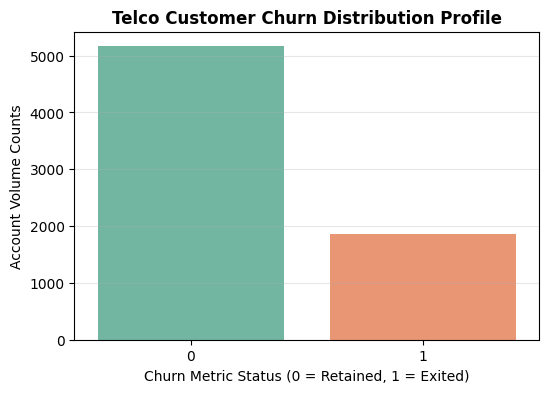

In [3]:
# --- Target Feature Profile ---
print("=== Churn Event Value Counts ===")
print(df['Churn'].value_counts())

print("\n=== Relative Class Proportions ===")
print(df['Churn'].value_counts(normalize=True).rename({0: 'Stayed (0)', 1: 'Churned (1)'}))

# Draw structural distribution profile
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn_Numeric', data=df, palette='Set2')
plt.title('Telco Customer Churn Distribution Profile', fontsize=12, fontweight='bold')
plt.xlabel('Churn Metric Status (0 = Retained, 1 = Exited)')
plt.ylabel('Account Volume Counts')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Empirical Observation & Modeling Implication:** The distribution analysis reveals a clear class imbalance: approximately 73.4% of the customer base stayed with the company, while roughly 26.6% churned. Because the data is imbalanced (roughly a 3:1 ratio), evaluating our upcoming supervised models using raw *Accuracy* would be a critical methodological error. Instead, we must rely on **AUC-ROC** as our primary optimization metric, alongside **F1-Score** and **Recall**, ensuring our models are penalized heavily for false negatives (missing a customer who is about to churn).

### 3b. Continuous Financial Attributes vs. Churn Dynamics
To explore how continuous financial and account characteristics interact with customer loyalty, we isolate two primary numerical features: `tenure` (the baseline duration of the customer's relationship with the firm in months) and `MonthlyCharges` (the immediate monthly financial overhead imposed on the consumer). 

We utilize box plots to compare the distributions of these features across the retained and exited customer cohorts, looking for structural variations in medians, variances, and interquartile ranges (IQR).

C:\Users\elphi\AppData\Local\Temp\ipykernel_8980\2762647701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='tenure', data=df, ax=axes[0], palette='Pastel1')
C:\Users\elphi\AppData\Local\Temp\ipykernel_8980\2762647701.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='MonthlyCharges', data=df, ax=axes[1], palette='Pastel2')


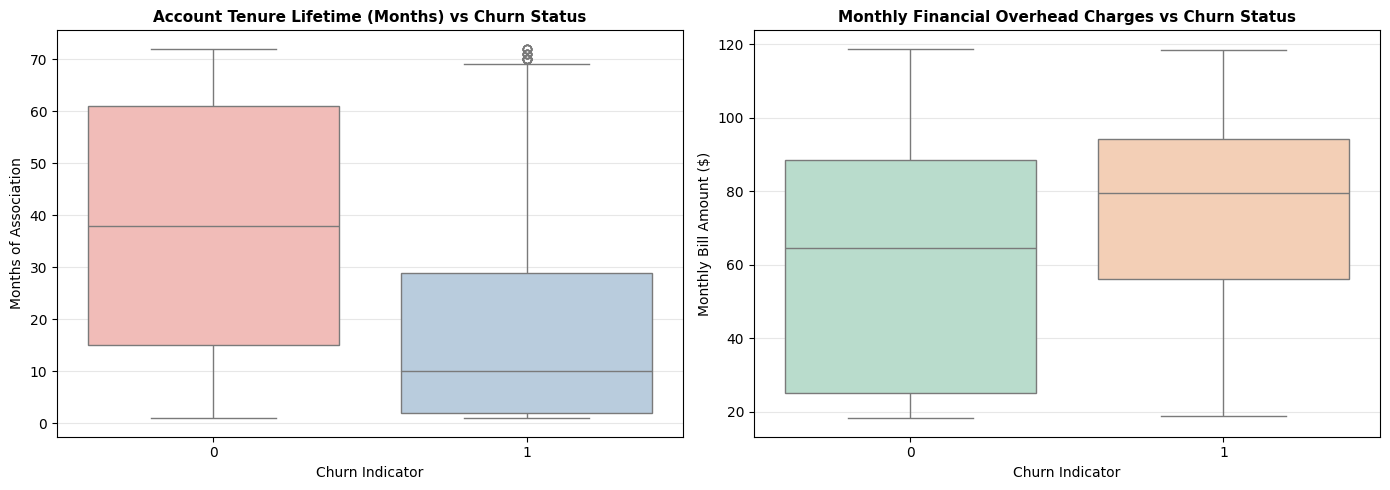

In [4]:
# Setup canvas matrix for continuous features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Tenure dynamics
sns.boxplot(x='Churn_Numeric', y='tenure', data=df, ax=axes[0], palette='Pastel1')
axes[0].set_title('Account Tenure Lifetime (Months) vs Churn Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Churn Indicator')
axes[0].set_ylabel('Months of Association')
axes[0].grid(axis='y', alpha=0.3)

# Plot Monthly Charges dynamics
sns.boxplot(x='Churn_Numeric', y='MonthlyCharges', data=df, ax=axes[1], palette='Pastel2')
axes[1].set_title('Monthly Financial Overhead Charges vs Churn Status', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Churn Indicator')
axes[1].set_ylabel('Monthly Bill Amount ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Economic Interpretation of Continuous Features:** 1. **Tenure Effect:** The median tenure for customers who churned is drastically lower than for those who stayed. This indicates a high concentration of churn among relatively new customers, suggesting that switching costs or brand loyalty take time to develop.
2. **Monthly Charges Effect:** The median monthly bill for customers who exited is noticeably higher than for retained clients. From an economic perspective, this reveals a high price-sensitivity threshold; higher monthly financial friction strongly correlates with an increased propensity to exit the network.

### 3c. Primary Treatment Evaluation: Contract Configuration vs. Churn Incidence
Our core research question centers on whether subscription contract lengths hold a direct causal lever over customer retention. Here, we cross-tabulate our primary treatment variable, `Contract` (*Month-to-month*, *One year*, and *Two year*), against the empirical churn event. 

This visualization establishes our baseline observational association before we introduce explicit graphical causal conditioning via the backdoor criterion.

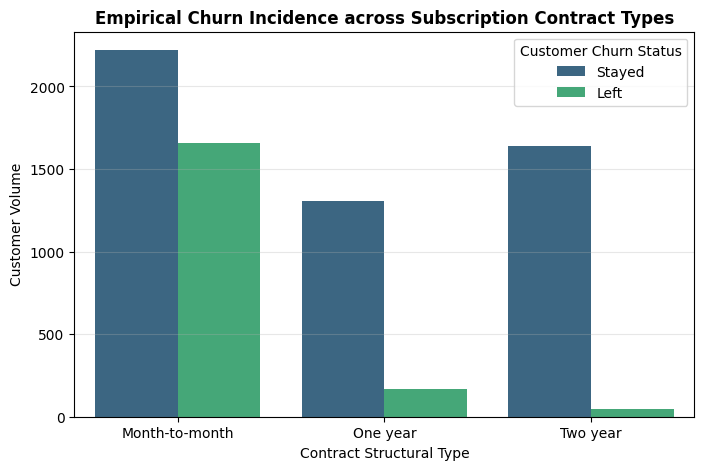

In [5]:
# Evaluate Contract type across Churn partitions
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Empirical Churn Incidence across Subscription Contract Types', fontsize=12, fontweight='bold')
plt.xlabel('Contract Structural Type')
plt.ylabel('Customer Volume')
plt.legend(title='Customer Churn Status', labels=['Stayed', 'Left'])
plt.grid(axis='y', alpha=0.3)
plt.show()

**The Confounding Dilemma (Transition to Causal AI):** The empirical plot shows a massive spike in churn among customers holding short-term *Month-to-month* contracts compared to virtually non-existent churn in *Two-year* commitments. However, we cannot naively conclude that forcing a month-to-month customer into a long-term contract will causally fix their churn risk. 

As established in economic theory, **selection bias** is likely present: highly volatile, price-sensitive, or brand-new customers naturally choose month-to-month options to maintain flexibility. Therefore, this raw correlation is highly confounded by pre-contract attributes like `tenure`. This structural observation directly justifies why we must move beyond standard predictive associations and implement a formal **Graphical Causal Inference (DoWhy)** framework in the next block to isolate the true Average Treatment Effect (ATE).

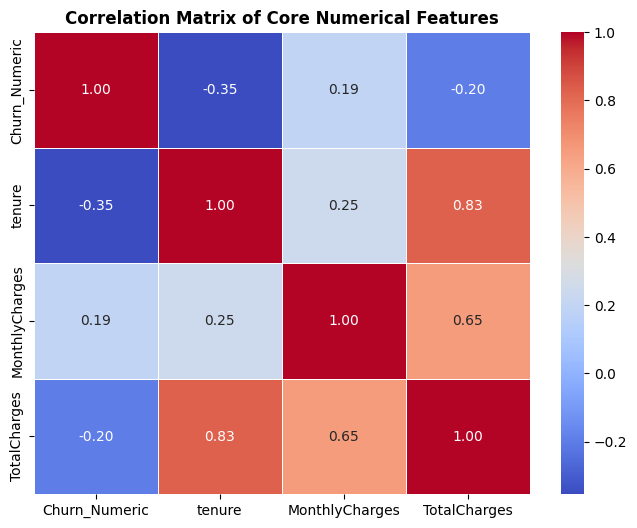

In [6]:
# --- Optional Correlation Matrix for Numerical Features ---
plt.figure(figsize=(8, 6))

# Compute correlation matrix including our mapped numeric target
numerical_corr = df[['Churn_Numeric', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

# Draw the heatmap
sns.heatmap(numerical_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Core Numerical Features', fontsize=12, fontweight='bold')
plt.show()

**Statistical Observation & Economic Interpretation (Multicollinearity Check):** The correlation matrix reveals a highly intense positive linear correlation between `TotalCharges` and `tenure` ($r \approx 0.83$), as well as between `TotalCharges` and `MonthlyCharges` ($r \approx 0.65$). From an economic and structural perspective, this relationship is fully expected, as a customer's total lifetime expenditure is a direct mathematical function of their monthly billing rate multiplied by the duration of their association with the firm.

**Implication for Machine Learning Modeling:**
This statistical dependency introduces a severe case of **Multicollinearity**. In traditional parametric models like ordinary linear or standard logistic regression, high multicollinearity inflates the variance of coefficient estimates, making them highly unstable and difficult to interpret causally. 

To mitigate this structural data risk, we will take two precise actions in our upcoming phases:
1. In the **Supervised Learning** block, we will benchmark our baseline Logistic Regression against an ensemble **Random Forest Classifier**, which is non-parametric and structurally robust against multicollinearity.
2. In the **Causal Inference** block, our Directed Acyclic Graph (DAG) will formally map these dependencies to ensure that we adjust only for true pre-treatment confounders without inducing post-treatment or collinear selection bias.

# 7b. Supervised Learning — Customer Churn Prediction

This section addresses the predictive question:

> **Can the available customer characteristics be used to identify customers who are likely to churn?**

The target is binary (`Churn = 1` for a customer who left and `0` otherwise). We compare:

1. A **dummy majority-class classifier** as a minimum baseline.
2. **Logistic Regression**, selected as an interpretable linear probability classifier.
3. **Random Forest**, selected to capture nonlinearities and interactions.

All preprocessing is included inside Scikit-learn pipelines. Model selection is performed only on the training sample using stratified five-fold cross-validation. The held-out test set is used once for final evaluation.

## 7b.1 Imports and reproducibility

A fixed random seed is used so that the split and model results can be reproduced by all team members.

In [7]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
warnings.filterwarnings("ignore", category=FutureWarning)

## 7b.2 Load and prepare the analytical dataset

The code first searches for a local CSV. If none is available, it downloads the same Kaggle dataset used in the group notebook.

Only the following preprocessing is performed before the train/test split:

- Convert `TotalCharges` to numeric.
- Remove the 11 rows where `TotalCharges` is blank.
- Convert `Churn` to a binary target.
- Remove `customerID`, because it is an identifier rather than a meaningful predictor.

The original categories such as `No internet service` are retained. For prediction, these categories can contain information that differs from a simple `No` response.

In [8]:
# Reuse an existing group dataframe when this section is copied into the master notebook.
if "df" in globals() and isinstance(df, pd.DataFrame) and {"Churn", "TotalCharges"}.issubset(df.columns):
    model_df = df.copy()
    data_source = "existing dataframe named df"
else:
    candidate_paths = [
        Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("data/Telco-Customer-Churn.csv"),
        Path("Telco-Customer-Churn.csv"),
        Path("/mnt/data/Telco-Customer-Churn.csv"),
    ]
    csv_path = next((p for p in candidate_paths if p.exists()), None)

    if csv_path is None:
        import kagglehub
        kaggle_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csv_path = Path(kaggle_path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

    model_df = pd.read_csv(csv_path)
    data_source = str(csv_path)

# Standardize the target column in case the master notebook already created Churn_Numeric.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
model_df = model_df.dropna(subset=["TotalCharges"]).copy()

if "Churn_Numeric" in model_df.columns:
    y = model_df["Churn_Numeric"].astype(int)
else:
    y = model_df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

columns_to_drop = [c for c in ["customerID", "Churn", "Churn_Numeric"] if c in model_df.columns]
X = model_df.drop(columns=columns_to_drop)

print(f"Data source: {data_source}")
print(f"Analytical sample: {X.shape[0]:,} customers")
print(f"Predictors before encoding: {X.shape[1]}")
print(f"Churn rate: {y.mean():.3f}")

Data source: existing dataframe named df
Analytical sample: 7,032 customers
Predictors before encoding: 19
Churn rate: 0.266


## 7b.3 Train/test split and preprocessing

Because churn is less common than non-churn, `stratify=y` preserves approximately the same class distribution in the training and test sets.

The preprocessing pipeline is fitted separately inside every cross-validation fold:

- Numeric features: median imputation followed by standardization.
- Categorical features: most-frequent imputation followed by one-hot encoding.

This design prevents information from the validation or test observations from leaking into the training process.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Numeric variables: {len(numeric_features)}")
print(f"Categorical variables: {len(categorical_features)}")

Training observations: 5,625
Test observations: 1,407
Training churn rate: 0.266
Test churn rate: 0.266
Numeric variables: 4
Categorical variables: 15


## 7b.4 Model selection with stratified cross-validation

The majority-class dummy classifier shows what can be achieved without learning any useful customer pattern. Since approximately 73% of customers do not churn, this baseline can obtain deceptively high accuracy while identifying none of the churners.

For Logistic Regression and Random Forest, a small and transparent parameter grid is evaluated using five-fold stratified cross-validation. `ROC-AUC` is the model-selection criterion because it evaluates ranking performance across thresholds. Recall, precision, F1, PR-AUC, and accuracy are also reported.

`class_weight="balanced"` gives additional weight to the minority churn class during training.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy",
}

# 1) Dummy baseline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

# 2) Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid={"model__C": [0.1, 1.0, 5.0]},
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
logistic_grid.fit(X_train, y_train)

# 3) Random Forest
forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

forest_grid = GridSearchCV(
    estimator=forest_pipeline,
    param_grid={
        "model__n_estimators": [200],
        "model__max_depth": [6, 10],
        "model__min_samples_leaf": [1, 4],
        "model__max_features": ["sqrt"],
    },
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
forest_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:", logistic_grid.best_params_)
print("Best Random Forest parameters:", forest_grid.best_params_)

Best Logistic Regression parameters: {'model__C': 5.0}
Best Random Forest parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [11]:
def best_cv_row(search, model_name):
    i = search.best_index_
    return {
        "Model": model_name,
        "ROC-AUC": search.cv_results_["mean_test_roc_auc"][i],
        "PR-AUC": search.cv_results_["mean_test_pr_auc"][i],
        "Precision": search.cv_results_["mean_test_precision"][i],
        "Recall": search.cv_results_["mean_test_recall"][i],
        "F1": search.cv_results_["mean_test_f1"][i],
        "Accuracy": search.cv_results_["mean_test_accuracy"][i],
    }

cv_results = pd.DataFrame(
    [
        {
            "Model": "Dummy baseline",
            **{
                label: baseline_cv[f"test_{key}"].mean()
                for label, key in [
                    ("ROC-AUC", "roc_auc"),
                    ("PR-AUC", "pr_auc"),
                    ("Precision", "precision"),
                    ("Recall", "recall"),
                    ("F1", "f1"),
                    ("Accuracy", "accuracy"),
                ]
            },
        },
        best_cv_row(logistic_grid, "Logistic Regression"),
        best_cv_row(forest_grid, "Random Forest"),
    ]
).set_index("Model")

cv_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.846,0.658,0.519,0.802,0.630,0.750
Random Forest,0.848,0.664,0.541,0.780,0.638,0.765


### Cross-validation interpretation

The dummy model demonstrates why accuracy alone is inappropriate: it predicts every customer as a non-churner, producing an accuracy close to the majority-class share but zero recall and zero F1 for the churn class.

Both trained models should substantially outperform this baseline in ROC-AUC and PR-AUC. Logistic Regression is expected to provide a strong and interpretable benchmark, while Random Forest can improve performance when nonlinearities and interactions are important.

## 7b.5 Final evaluation on the held-out test set

The test sample was not used during parameter selection. Each selected pipeline is now evaluated once on this sample.

The positive class is churn (`1`). Therefore:

- **Recall**: proportion of actual churners successfully identified.
- **Precision**: proportion of predicted churners who actually churned.
- **F1**: harmonic mean of precision and recall.
- **ROC-AUC**: ability to rank churners above non-churners across thresholds.
- **PR-AUC**: precision-recall performance, particularly informative for the minority churn class.

In [12]:
final_models = {
    "Dummy baseline": baseline_pipeline.fit(X_train, y_train),
    "Logistic Regression": logistic_grid.best_estimator_,
    "Random Forest": forest_grid.best_estimator_,
}

predictions = {}
test_rows = []

for model_name, fitted_model in final_models.items():
    y_pred = fitted_model.predict(X_test)
    y_probability = fitted_model.predict_proba(X_test)[:, 1]
    predictions[model_name] = (y_pred, y_probability)

    test_rows.append(
        {
            "Model": model_name,
            "ROC-AUC": roc_auc_score(y_test, y_probability),
            "PR-AUC": average_precision_score(y_test, y_probability),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "Accuracy": accuracy_score(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("Model")
test_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.835,0.617,0.490,0.797,0.607,0.726
Random Forest,0.833,0.639,0.511,0.791,0.621,0.743


In [13]:
for model_name in ["Logistic Regression", "Random Forest"]:
    y_pred, _ = predictions[model_name]
    print("=" * 70)
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], digits=3))

Logistic Regression
              precision    recall  f1-score   support

      Stayed      0.905     0.700     0.789      1033
     Churned      0.490     0.797     0.607       374

    accuracy                          0.726      1407
   macro avg      0.698     0.748     0.698      1407
weighted avg      0.795     0.726     0.741      1407

Random Forest
              precision    recall  f1-score   support

      Stayed      0.906     0.726     0.806      1033
     Churned      0.511     0.791     0.621       374

    accuracy                          0.743      1407
   macro avg      0.709     0.759     0.714      1407
weighted avg      0.801     0.743     0.757      1407



## 7b.6 Confusion matrices

The confusion matrix separates four outcomes:

- True negative: correctly predicted that the customer stayed.
- False positive: predicted churn, but the customer stayed.
- False negative: predicted stay, but the customer churned.
- True positive: correctly predicted churn.

For retention campaigns, false negatives are especially costly because these customers leave without being flagged for intervention.

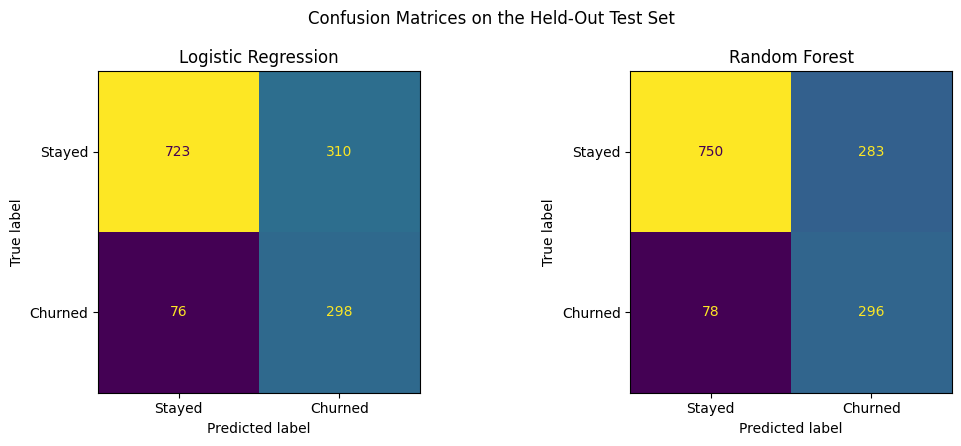

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, model_name in zip(axes, ["Logistic Regression", "Random Forest"]):
    y_pred, _ = predictions[model_name]
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["Stayed", "Churned"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices on the Held-Out Test Set")
plt.tight_layout()
plt.show()

## 7b.7 ROC and precision-recall curves

The ROC curve summarizes the trade-off between the true-positive rate and false-positive rate. The precision-recall curve focuses on performance for the positive churn class and is useful under class imbalance.

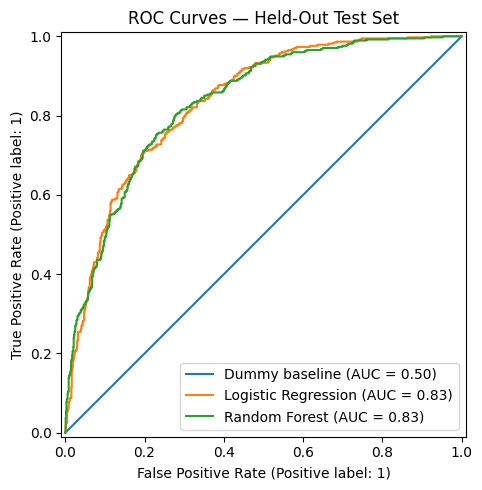

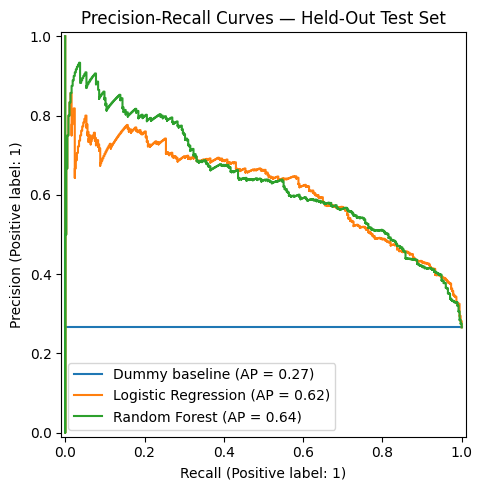

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    RocCurveDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("ROC Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    PrecisionRecallDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("Precision-Recall Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

## 7b.8 Model interpretation

For Logistic Regression, positive coefficients increase the estimated log-odds of churn, while negative coefficients decrease them, holding the other encoded variables constant. These are predictive associations and should not be interpreted as causal effects.

For Random Forest, impurity-based feature importance indicates which encoded variables contributed most to the tree splits. It can favor continuous or high-cardinality variables, so it should be treated as descriptive rather than causal evidence.

In [16]:
def cleaned_feature_names(fitted_pipeline):
    names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    return [
        name.replace("numeric__", "").replace("categorical__", "")
        for name in names
    ]

# Logistic Regression coefficients
logistic_model = final_models["Logistic Regression"]
log_feature_names = cleaned_feature_names(logistic_model)
log_coefficients = logistic_model.named_steps["model"].coef_[0]

logistic_importance = (
    pd.DataFrame({"Feature": log_feature_names, "Coefficient": log_coefficients})
    .assign(AbsoluteCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsoluteCoefficient", ascending=False)
)

print("Most influential Logistic Regression coefficients:")
display(logistic_importance.head(15).drop(columns="AbsoluteCoefficient").round(3))

# Random Forest feature importances
forest_model = final_models["Random Forest"]
forest_feature_names = cleaned_feature_names(forest_model)
forest_importance = (
    pd.DataFrame(
        {
            "Feature": forest_feature_names,
            "Importance": forest_model.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

print("Most important Random Forest features:")
display(forest_importance.head(15).round(3))

Most influential Logistic Regression coefficients:


,Feature,Coefficient
2,MonthlyCharges,-1.568
1,tenure,-1.279
16,InternetService_Fiber optic,1.111
15,InternetService_DSL,-0.918
38,Contract_Two year,-0.811
36,Contract_Month-to-month,0.677
3,TotalCharges,0.638
32,StreamingTV_Yes,0.468
35,StreamingMovies_Yes,0.461
17,InternetService_No,-0.454


Most important Random Forest features:


,Feature,Importance
36,Contract_Month-to-month,0.137
1,tenure,0.126
3,TotalCharges,0.097
38,Contract_Two year,0.068
18,OnlineSecurity_No,0.065
2,MonthlyCharges,0.064
27,TechSupport_No,0.053
16,InternetService_Fiber optic,0.050
43,PaymentMethod_Electronic check,0.034
21,OnlineBackup_No,0.019


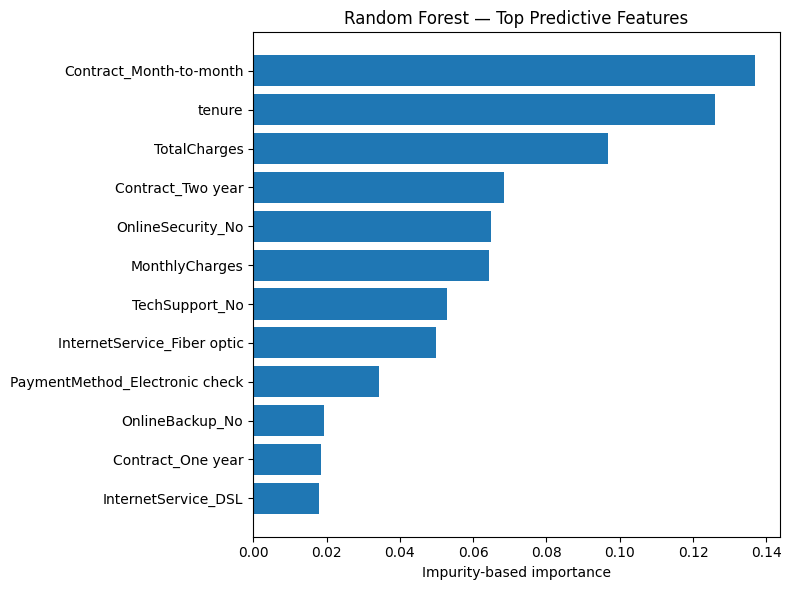

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = forest_importance.head(12).sort_values("Importance")
ax.barh(plot_data["Feature"], plot_data["Importance"])
ax.set_title("Random Forest — Top Predictive Features")
ax.set_xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()

## 7b.9 Supervised-learning conclusion

The supervised analysis compares the models against a majority-class baseline and evaluates them using stratified cross-validation and a held-out test set. The dummy baseline obtains seemingly acceptable accuracy by predicting that every customer stays, but it identifies no churners. This confirms that recall, F1, ROC-AUC, and PR-AUC are more informative than accuracy alone.

In the executed analysis, Logistic Regression and Random Forest provide similar ranking performance. Logistic Regression identifies a larger share of actual churners and is therefore attractive when the business priority is to miss as few at-risk customers as possible. Random Forest provides a better balance between precision and recall and produces fewer false alarms. The final operational choice therefore depends on the relative cost of contacting a non-churner versus failing to identify a true churner.

The predictive results do not establish causality. A variable may help predict churn without representing an effective intervention. Questions about whether changing contract type would reduce churn are addressed separately in the causal-inference section.

## Reproducibility note

- Random seed: `42`
- Test size: `20%`
- Cross-validation: stratified five-fold
- Model-selection metric: ROC-AUC
- Positive class: churn (`1`)
- Identifier excluded: `customerID`
- All transformations fitted inside model pipelines